## Custom Dataset walkthrough

This notebook demonstrates how to compose the `ClimbingDataset`, inspect a sampled route,
and measure performance characteristics of the resulting dataloaders.

In [2]:
# -- Notebook setup
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

# Project modules
from utils import *
from utils_visualisation import *
from Data_Handler import ClimbingDataset

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

# Image filters
import kornia.filters as KF

### Configure dataset
Set up optional transforms and instantiate the `ClimbingDataset` with the boards and filters we want to analyse.
- `board_names`: choose one or more board layouts to include (matched against the SQLite exports).
- `map`: if `True`, remaps sparse hold coordinates into a dense grid so CNN kernels can operate without gaps.
- `transform`: optional Kornia transform applied to each sample; here we blur hold activations slightly.
- `label_filter`: restricts the dataset to specific difficulty indices (see `Data_Handler` for label mapping).
- `max_samples`: upper bound on the number of routes to load, keeping experimentation lightweight.

In [9]:
# Load two boards, remap coordinates to a dense grid, and keep a subset of grades
climbing_DB = ClimbingDataset(
    board_names=["12 x 12 with kickboard Square", "8 x 12 Home"],  # mix wall layouts
    map=True,  # compress coordinates to contiguous indices
    label_filter=[5, 14],  # limit to a pair of grade levels for faster experimentation
    max_samples=5000,  # cap total routes so the notebook stays responsive
)

### Inspect a sample route
Peek at a single example to confirm tensor shapes and visualise the climbing problem.

Total routes available: 5,000
Feature tensor shape: torch.Size([1, 4, 35, 35]); one-hot label shape: torch.Size([21])


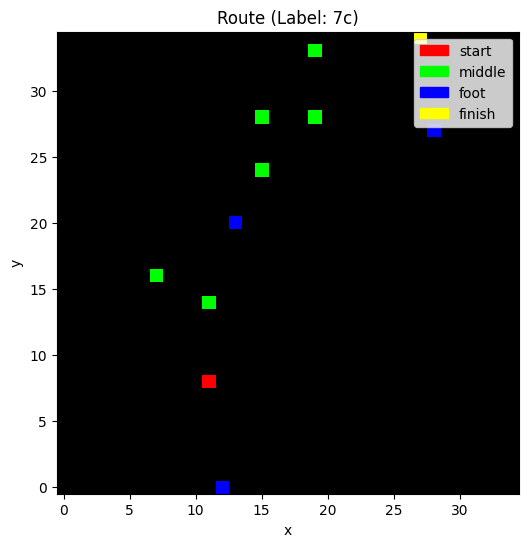

In [10]:
print(f"Total routes available: {len(climbing_DB):,}")

# Grab a representative example for visual inspection
X, y = climbing_DB[15]
print(f"Feature tensor shape: {X.shape}; one-hot label shape: {y.shape}")
plot_route(X, torch.argmax(y))

### Build train/test splits
Create deterministic train/test subsets, wrap them in dataloaders, and estimate memory usage.

In [11]:
# Compute deterministic train/test split indices
train_size = int(0.8 * len(climbing_DB))
test_size = len(climbing_DB) - train_size

train_dataset, test_dataset = random_split(
    climbing_DB,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

# Spawn dataloaders with pinned memory for optional GPU training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Approximate the total tensor footprint across both splits
total_bytes = 0
for dataset in (train_dataset, test_dataset):
    for data, target in dataset:
        if isinstance(data, torch.Tensor):
            total_bytes += data.element_size() * data.nelement()
        if isinstance(target, torch.Tensor):
            total_bytes += target.element_size() * target.nelement()

approx_mb = total_bytes / 1e6
print(f"Approx dataset tensor size: {approx_mb:.2f} MB")

Train samples: 4000, Test samples: 1000
Approx dataset tensor size: 98.42 MB


### Measure dataloader throughput
Benchmark how long it takes to iterate through a subset of batches for performance awareness.

In [12]:
# Measure average batch loading time over a subset of iterations
avg_batch_time_ms = measure_loader_time(train_loader, num_batches=200)

/home/fillies/Documents/moon/kilter/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Average batch load time: 3.71 ms over 124 batches


### Summarise label distribution
Use helper utilities to report hold statistics and compare train/test grade balance.

Hold statistics per difficulty:

Class 6a+:
  Avg total holds: 13.44
  Avg role composition: start=1.83, middle=5.37, foot=5.06, finish=1.19

Class 7c:
  Avg total holds: 11.17
  Avg role composition: start=1.69, middle=4.66, foot=3.78, finish=1.04

Train distribution:
  Class 6a+: 1844.0 (46.1%)
  Class 7c: 2156.0 (53.9%)

Test distribution:
  Class 6a+: 431.0 (43.1%)
  Class 7c: 569.0 (56.9%)


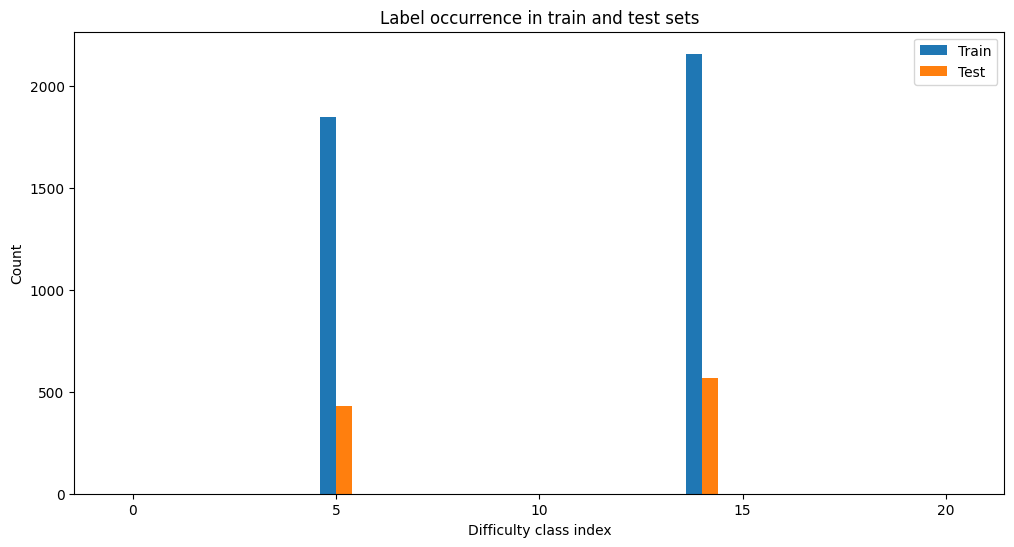

In [13]:
# Aggregate per-grade hold counts and role breakdowns
print_hold_statistics(train_dataset, num_classes=climbing_DB.num_classes)

# Compare grade distribution between train and test splits
plot_label_distribution(train_dataset, test_dataset, num_classes=climbing_DB.num_classes)

### Visualise sample routes
Render a few randomly selected problems to validate the dataset looks correct.

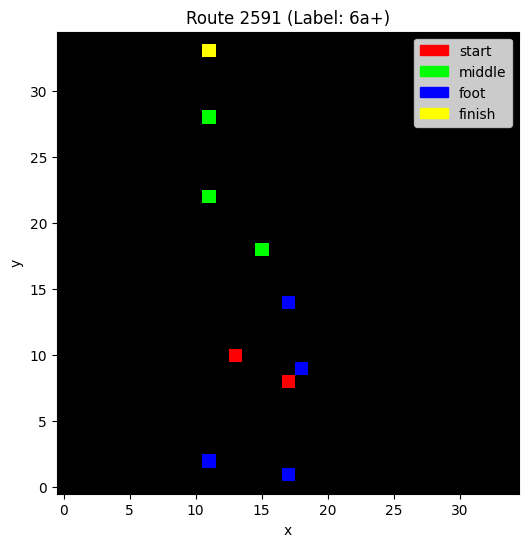

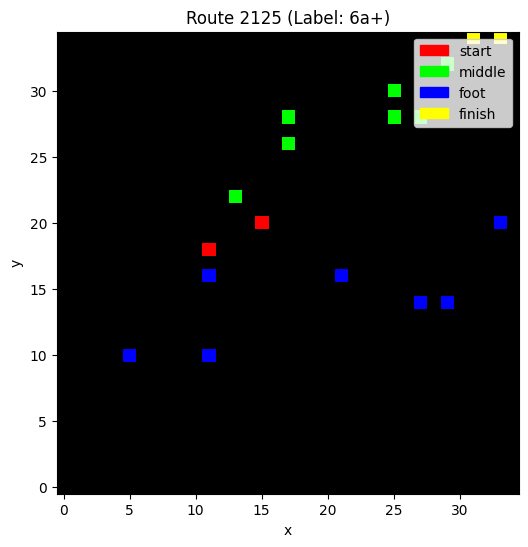

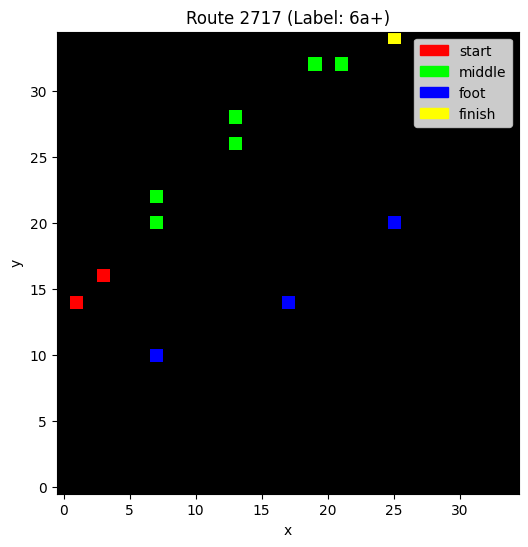

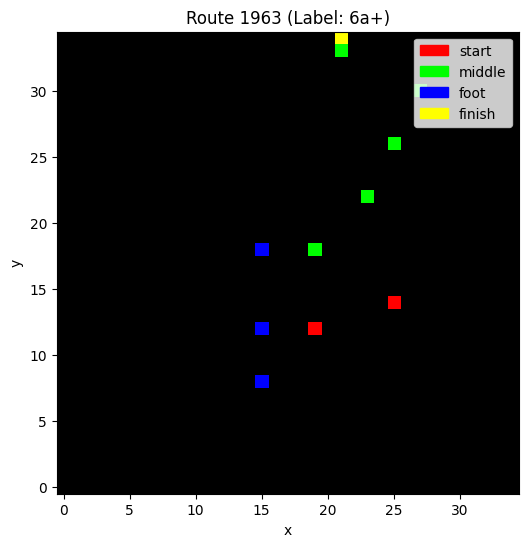

In [14]:
# Visual sanity check across multiple grades
plot_sample_routes(train_dataset, n=4, grades=[f"V{i}" for i in range(climbing_DB.num_classes)])